# Estudo de Ablação: Avaliação Automática de Respostas Curtas (ASAG)

Este notebook executa e documenta os experimentos de predição de notas para o dataset `df_11`. 
O objetivo é avaliar o impacto de diferentes conjuntos de características (Embeddings, TF-IDF e métricas linguísticas do Coh-Metrix) utilizando diversos modelos de regressão clássicos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import nltk
from sentence_transformers import SentenceTransformer
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from nltk.corpus import stopwords
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer

# Configurações iniciais
nltk.download('stopwords', quiet=True)
stop_words_pt = stopwords.words('portuguese')
pd.set_option('display.max_rows', None) 

c:\Users\Valdir Junior\Downloads\drive-download-20260419T232244Z-3-001\nlp-main\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carregamento dos Dados
Nesta etapa, carregamos os arquivos CSV de treino e teste. Certifique-se de que o notebook está na raiz do projeto para que o caminho relativo funcione corretamente.

In [2]:
DATASET = "df_11"
PASTA = "dataset" 

print(f"Carregando os datasets de treino e teste ({DATASET})...")
df_train = pd.read_csv(os.path.join(PASTA, f"{DATASET}_train.csv"))
df_test  = pd.read_csv(os.path.join(PASTA, f"{DATASET}_test.csv"))

COL_TEXTO = "answer_text"
COL_NOTA  = "grade"

print(f"Treino: {len(df_train)} amostras | Teste: {len(df_test)} amostras")

textos_train = df_train[COL_TEXTO].fillna("").astype(str).tolist()
textos_test  = df_test[COL_TEXTO].fillna("").astype(str).tolist()

y_train = df_train[COL_NOTA].reset_index(drop=True)
y_test  = df_test[COL_NOTA].reset_index(drop=True)

Carregando os datasets de treino e teste (df_11)...
Treino: 7220 amostras | Teste: 2642 amostras


## 2. Extração de Características (Features)
Geração das representações vetoriais dos textos utilizando modelos de linguagem (Sentence Transformers) e abordagens baseadas em frequência (TF-IDF).

In [3]:
print("Gerando Embeddings (Sentence Transformers)...")
modelo_ia = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

emb_train = modelo_ia.encode(textos_train, show_progress_bar=True)
emb_test  = modelo_ia.encode(textos_test,  show_progress_bar=True)

cols_emb = [f"emb_{i}" for i in range(emb_train.shape[1])]
df_emb_train = pd.DataFrame(emb_train, columns=cols_emb)
df_emb_test  = pd.DataFrame(emb_test,  columns=cols_emb)

print("Gerando TF-IDF...")
tfidf_vec = TfidfVectorizer(max_features=1000, stop_words=stop_words_pt)
tfidf_vec.fit(textos_train) 

cols_tfidf = tfidf_vec.get_feature_names_out()
df_tfidf_train = pd.DataFrame(tfidf_vec.transform(textos_train).toarray(), columns=cols_tfidf)
df_tfidf_test  = pd.DataFrame(tfidf_vec.transform(textos_test).toarray(),  columns=cols_tfidf)

Gerando Embeddings (Sentence Transformers)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5685.43it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 83/83 [00:14<00:00,  5.75it/s]


Gerando TF-IDF...


## 3. Integração com o Coh-Metrix
Carregamento das métricas linguísticas previamente extraídas pelo Coh-Metrix e junção (merge) com os dados atuais com base no texto original da resposta.

In [4]:
print("Verificando features Coh-Metrix...")
ficheiro_cohmetrix = "tools/caracteristicas_cohmetrix_BKP.csv" # Caminho ajustado
usar_cohmetrix = os.path.exists(ficheiro_cohmetrix)

if usar_cohmetrix:
    df_coh = pd.read_csv(ficheiro_cohmetrix)
    colunas_drop     = ['resposta_original', 'nota_original']
    colunas_features = [c for c in df_coh.columns if c not in colunas_drop]
    df_coh_dedup = df_coh.drop_duplicates(subset='resposta_original').reset_index(drop=True)

    def limpar_para_merge(texto):
        texto = str(texto).lower() 
        texto = re.sub(r'\s+', ' ', texto)
        return texto.strip()
        
    df_train['chave_merge'] = df_train['answer_text'].apply(limpar_para_merge)
    df_test['chave_merge']  = df_test['answer_text'].apply(limpar_para_merge)
    df_coh_dedup['chave_merge'] = df_coh_dedup['resposta_original'].apply(limpar_para_merge)
    
    df_train_coh = df_train.merge(df_coh_dedup, on='chave_merge', how='inner').reset_index(drop=True)
    df_test_coh = df_test.merge(df_coh_dedup, on='chave_merge', how='inner').reset_index(drop=True)

    coh_train   = df_train_coh[colunas_features].fillna(0).reset_index(drop=True)
    coh_test    = df_test_coh[colunas_features].fillna(0).reset_index(drop=True)
    y_train_coh = df_train_coh['grade'].reset_index(drop=True)
    y_test_coh  = df_test_coh['grade'].reset_index(drop=True)

    textos_train_coh = df_train_coh['answer_text'].fillna("").astype(str).tolist()
    textos_test_coh  = df_test_coh['answer_text'].fillna("").astype(str).tolist()

    emb_train_coh = modelo_ia.encode(textos_train_coh, show_progress_bar=False)
    emb_test_coh  = modelo_ia.encode(textos_test_coh,  show_progress_bar=False)
    df_emb_train_coh = pd.DataFrame(emb_train_coh, columns=cols_emb)
    df_emb_test_coh  = pd.DataFrame(emb_test_coh,  columns=cols_emb)

    df_tfidf_train_coh = pd.DataFrame(tfidf_vec.transform(textos_train_coh).toarray(), columns=cols_tfidf)
    df_tfidf_test_coh  = pd.DataFrame(tfidf_vec.transform(textos_test_coh).toarray(),  columns=cols_tfidf)

    print(f"Coh-Metrix: {len(coh_train)} treino / {len(coh_test)} teste (após merge)")
else:
    print("AVISO: Arquivo Coh-Metrix não encontrado.")

Verificando features Coh-Metrix...
Coh-Metrix: 3554 treino / 1360 teste (após merge)


## 4. Configuração dos Cenários e Modelos
Preparação das diferentes combinações de features (Ablation Study) e instanciação dos algoritmos de Machine Learning que serão treinados.

In [5]:
if usar_cohmetrix:
    cenarios = {
        "Apenas TF-IDF": (df_tfidf_train, df_tfidf_test, y_train, y_test, df_test),
        "Apenas Embeddings": (df_emb_train, df_emb_test, y_train, y_test, df_test),
        "Apenas Coh-Metrix": (coh_train, coh_test, y_train_coh, y_test_coh, df_test_coh),
        "TF-IDF + Embeddings": (pd.concat([df_tfidf_train, df_emb_train], axis=1), pd.concat([df_tfidf_test,  df_emb_test],  axis=1), y_train, y_test, df_test),
        "TF-IDF + Coh-Metrix": (pd.concat([df_tfidf_train_coh, coh_train], axis=1), pd.concat([df_tfidf_test_coh,  coh_test],  axis=1), y_train_coh, y_test_coh, df_test_coh),
        "Coh-Metrix + Embeddings": (pd.concat([coh_train, df_emb_train_coh], axis=1), pd.concat([coh_test,  df_emb_test_coh],  axis=1), y_train_coh, y_test_coh, df_test_coh),
        "Tudo (TF-IDF + Coh-Metrix + Emb)": (pd.concat([df_tfidf_train_coh, coh_train, df_emb_train_coh], axis=1), pd.concat([df_tfidf_test_coh,  coh_test,  df_emb_test_coh],  axis=1), y_train_coh, y_test_coh, df_test_coh),
    }
else:
    cenarios = {
        "Apenas TF-IDF": (df_tfidf_train, df_tfidf_test, y_train, y_test, df_test),
        "Apenas Embeddings": (df_emb_train, df_emb_test, y_train, y_test, df_test),
        "TF-IDF + Embeddings": (pd.concat([df_tfidf_train, df_emb_train], axis=1), pd.concat([df_tfidf_test,  df_emb_test],  axis=1), y_train, y_test, df_test),
    }

modelos = {
    "Regressão Linear":     LinearRegression(),
    "KNN":                  KNeighborsRegressor(n_neighbors=5),
    "SVR":                  SVR(),
    "Árvore de Decisão":    DecisionTreeRegressor(random_state=42),
    "Random Forest":        RandomForestRegressor(n_estimators=100, random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),
    "Rede Neural (MLP)":    MLPRegressor(random_state=42, max_iter=1000),
}
print("Modelos e cenários carregados em memória.")

Modelos e cenários carregados em memória.


## 5. Treinamento e Avaliação
Execução do loop principal. Os dados são padronizados (`StandardScaler`) antes de treinar cada algoritmo e as métricas MAE, RMSE e R² são calculadas.

In [6]:
print("Iniciando treinamento...\n")

resultados_gerais     = []
melhor_r2_global      = -float('inf')
melhor_modelo_global  = None
nome_melhor_modelo    = ""
melhor_cenario_global = ""
previsoes_melhor      = None
X_test_melhor         = None
y_test_melhor_ref     = None
df_test_melhor        = None

for nome_cenario, (X_train_c, X_test_c, y_tr, y_te, df_te) in cenarios.items():
    X_train_c = X_train_c.reset_index(drop=True)
    X_test_c  = X_test_c.reset_index(drop=True)
    y_tr      = y_tr.reset_index(drop=True)
    y_te      = y_te.reset_index(drop=True)
    
    scaler = StandardScaler()
    colunas = X_train_c.columns 
    X_train_c = pd.DataFrame(scaler.fit_transform(X_train_c), columns=colunas)
    X_test_c = pd.DataFrame(scaler.transform(X_test_c), columns=colunas)
    
    for nome_modelo, modelo_base in modelos.items():
        modelo = clone(modelo_base)
        modelo.fit(X_train_c, y_tr)
        y_pred = modelo.predict(X_test_c)

        mae  = mean_absolute_error(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        r2   = r2_score(y_te, y_pred)

        resultados_gerais.append({
            "Dataset": DATASET,
            "Cenário": nome_cenario,
            "Modelo":  nome_modelo,
            "MAE":     mae,
            "RMSE":    rmse,
            "R²":      r2,
        })

        if r2 > melhor_r2_global:
            melhor_r2_global      = r2
            melhor_modelo_global  = modelo
            nome_melhor_modelo    = nome_modelo
            melhor_cenario_global = nome_cenario
            previsoes_melhor      = y_pred
            X_test_melhor         = X_test_c
            y_test_melhor_ref     = y_te
            df_test_melhor        = df_te

print("Treinamento finalizado.")

Iniciando treinamento...

Treinamento finalizado.


## 6. Resultados, Análise de Erros e Importância das Features
Apresentação da tabela de performance de todos os modelos, observação qualitativa das respostas onde o melhor modelo falhou e gráfico das características mais impactantes.

=== RANKING DE MODELOS (df_11) ===


,Dataset,Cenário,Modelo,MAE,RMSE,R²
0,df_11,Apenas Embeddings,HistGradientBoosting,0.4850,0.7379,0.3137
1,df_11,Apenas Embeddings,SVR,0.4996,0.7419,0.3063
2,df_11,TF-IDF + Embeddings,HistGradientBoosting,0.5027,0.7505,0.2901
3,df_11,TF-IDF + Embeddings,Random Forest,0.5044,0.7590,0.2739
4,df_11,Apenas Embeddings,Random Forest,0.5104,0.7644,0.2635
5,df_11,Apenas Embeddings,Regressão Linear,0.5159,0.7648,0.2627
6,df_11,TF-IDF + Embeddings,SVR,0.5208,0.7698,0.2531
7,df_11,Apenas TF-IDF,SVR,0.5516,0.8117,0.1695
8,df_11,Apenas TF-IDF,Random Forest,0.5408,0.8288,0.1343
9,df_11,Apenas TF-IDF,HistGradientBoosting,0.5717,0.8387,0.1134



=== PIORES PREDIÇÕES: HistGradientBoosting | Apenas Embeddings ===

> REAL: 3 | IA: -0.09 (Erro: 3.09)
RESPOSTA: O tecido epitelial é formado por células muito unidas pelas junções intercelulares.

> REAL: 3 | IA: 0.46 (Erro: 2.54)
RESPOSTA: O genótipo pode ser definido como a constituição genética de um indivíduo ou seja o conjunto de genes recebidos do pai e da mãe. são esses gênes juntamente as influências do meio que determinarão o fenótipo de um ser.

> REAL: 3 | IA: 0.49 (Erro: 2.51)
RESPOSTA: fenótipo características físicas genótipo : constituição genética

> REAL: 3 | IA: 0.51 (Erro: 2.49)
RESPOSTA: Proteção, revestimento.

> REAL: 3 | IA: 0.52 (Erro: 2.48)
RESPOSTA: O genótipo é a constituição genética do indivíduo, o conjunto de genes adquiridos do pai e da mãe. O fenótipo é a manifestação visível do genótipo.

=== IMPORTÂNCIA DAS FEATURES ===


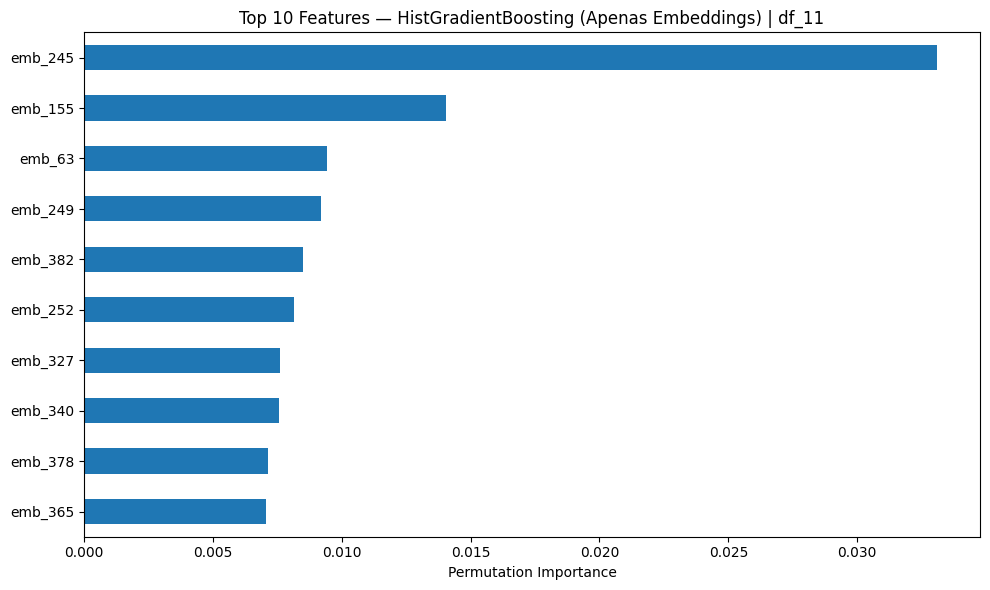

In [7]:
df_resultados = pd.DataFrame(resultados_gerais).sort_values(by="R²", ascending=False).reset_index(drop=True)
nome_resultado = f"resultados_{DATASET}.csv"
df_resultados.to_csv(nome_resultado, index=False)

print(f"=== RANKING DE MODELOS ({DATASET}) ===")
display(df_resultados.round(4))

print(f"\n=== PIORES PREDIÇÕES: {nome_melhor_modelo} | {melhor_cenario_global} ===")
df_analise = pd.DataFrame({
    'Texto':         df_test_melhor[COL_TEXTO].reset_index(drop=True),
    'Real':          y_test_melhor_ref.values,
    'Previsto':      previsoes_melhor,
    'Erro_Absoluto': np.abs(y_test_melhor_ref.values - previsoes_melhor),
})

piores = df_analise.sort_values(by='Erro_Absoluto', ascending=False).head(5)
for _, linha in piores.iterrows():
    print(f"\n> REAL: {linha['Real']} | IA: {linha['Previsto']:.2f} (Erro: {linha['Erro_Absoluto']:.2f})")
    print(f"RESPOSTA: {linha['Texto']}")

print("\n=== IMPORTÂNCIA DAS FEATURES ===")
try:
    resultado_imp = permutation_importance(
        melhor_modelo_global, X_test_melhor, y_test_melhor_ref,
        n_repeats=5, random_state=42, n_jobs=-1
    )
    importancias = pd.Series(resultado_imp.importances_mean, index=X_test_melhor.columns)
    top_10 = importancias.sort_values(ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    top_10.sort_values().plot(kind='barh', color='#1f77b4')
    plt.title(f"Top 10 Features — {nome_melhor_modelo} ({melhor_cenario_global}) | {DATASET}")
    plt.xlabel("Permutation Importance")
    plt.tight_layout()
    plt.savefig(f"resultado_importancia_{DATASET}.png", dpi=300)
    plt.show() 
except Exception as e:
    print(f"Não foi possível gerar o gráfico: {e}")